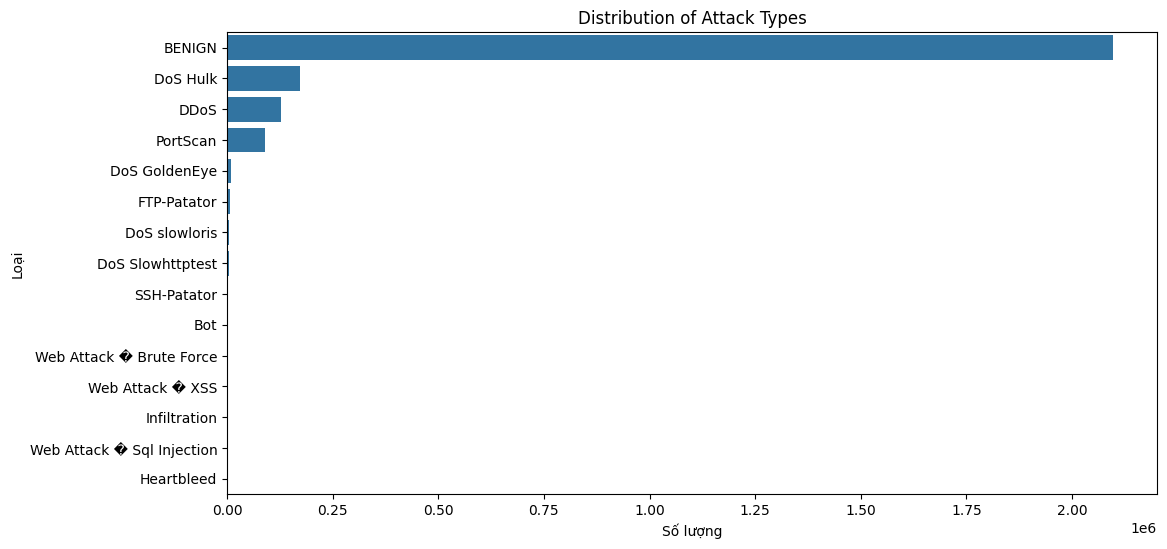

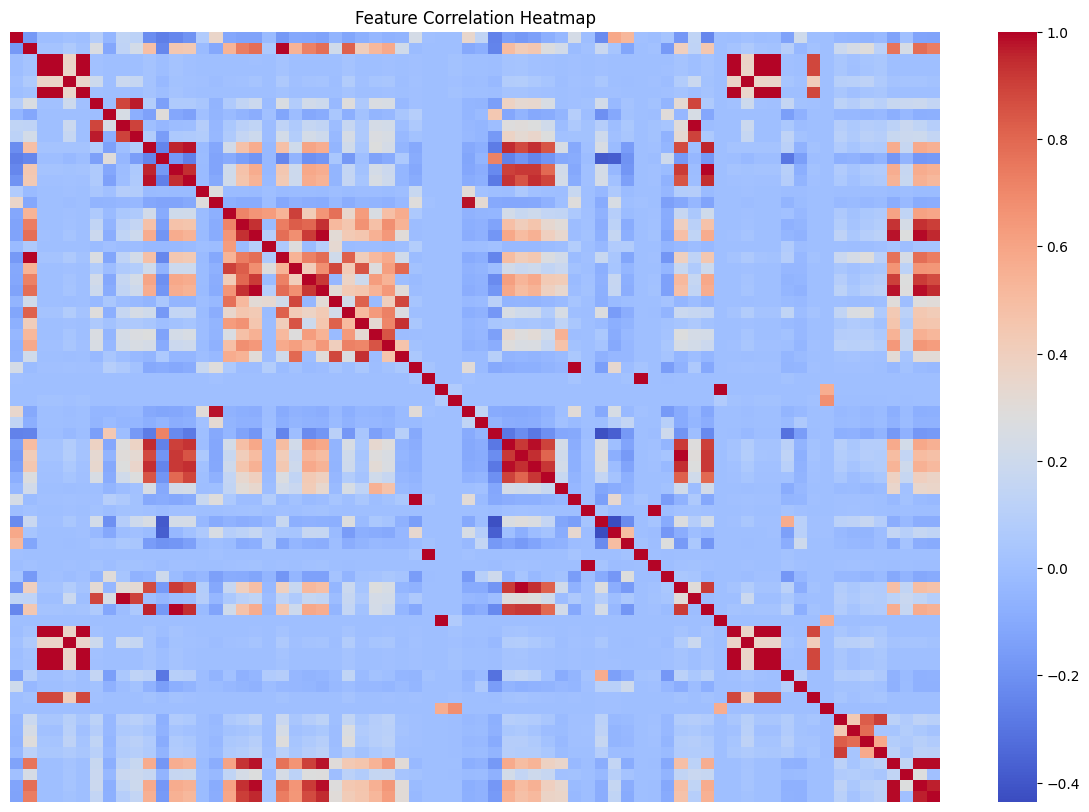

In [5]:
# Biểu đồ 1: Phân bố các loại tấn công
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Label', order=df['Label'].value_counts().index)
plt.title('Distribution of Attack Types')
plt.xlabel('Số lượng')
plt.ylabel('Loại')
plt.show()

# Biểu đồ 2: Heatmap tương quan giữa các cột
plt.figure(figsize=(15, 10))
# Lấy các cột dạng số để tính tương quan
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title('Feature Correlation Heatmap')
plt.show()

In [4]:
print("Đang tiến hành ép kiểu dữ liệu để tối ưu RAM...")

for col in df.columns:
    # Nếu là cột số thực (float)
    if 'float' in str(df[col].dtype):
        df[col] = pd.to_numeric(df[col], downcast='float')
    # Nếu là cột số nguyên (int)
    elif 'int' in str(df[col].dtype):
        df[col] = pd.to_numeric(df[col], downcast='integer')

print("Đã ép kiểu dữ liệu xong, RAM đã được giải phóng bớt!")

Đang tiến hành ép kiểu dữ liệu để tối ưu RAM...
Đã ép kiểu dữ liệu xong, RAM đã được giải phóng bớt!


In [2]:
# 1. Xóa khoảng trắng thừa ở tên cột
df.columns = df.columns.str.strip()

# 2. Thay thế giá trị vô hạn (inf) bằng NaN, sau đó điền NaN bằng giá trị trung vị (median)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Xóa các dòng trùng lặp
df.drop_duplicates(inplace=True)

# 4. Xóa các cột chỉ có 1 giá trị duy nhất (phương sai bằng 0)
df = df.loc[:, df.nunique() > 1]
print("Làm sạch xong! Kích thước dữ liệu:", df.shape)

Làm sạch xong! Kích thước dữ liệu: (2522362, 71)


In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Tắt cảnh báo vặt cho đỡ rối mắt

# Đọc tất cả các file csv trong thư mục data
file_paths = glob.glob('data/*.csv') 
df = pd.concat([pd.read_csv(f) for f in file_paths], ignore_index=True)
print("Đã gộp xong! Kích thước dữ liệu hiện tại:", df.shape)


Đã gộp xong! Kích thước dữ liệu hiện tại: (2830743, 79)
